# Detection method vs Planet properties

In [155]:
from math import log10

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as st

In [156]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Detection Method vs Planet Properties': ['There is no difference in planet radius/mass across different discovery methods.', 'Different discovery methods detect different types of planets (Transit = smaller planets).']
}
detection_method_hypotheses = pd.DataFrame(data)
detection_method_hypotheses

,Hypothesis,Detection Method vs Planet Properties
0,H0,There is no difference in planet radius/mass a...
1,H1,Different discovery methods detect different t...


In [157]:
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


#### Discovery methods
---

In [158]:
# Analysis of planet detection methods
# Checking the counts of all detection methods
detection_methods = data['discovery_method'].value_counts()
detection_methods

discovery_method
Transit                          4517
Radial Velocity                  1182
Microlensing                      275
Imaging                            94
Transit Timing Variations          39
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

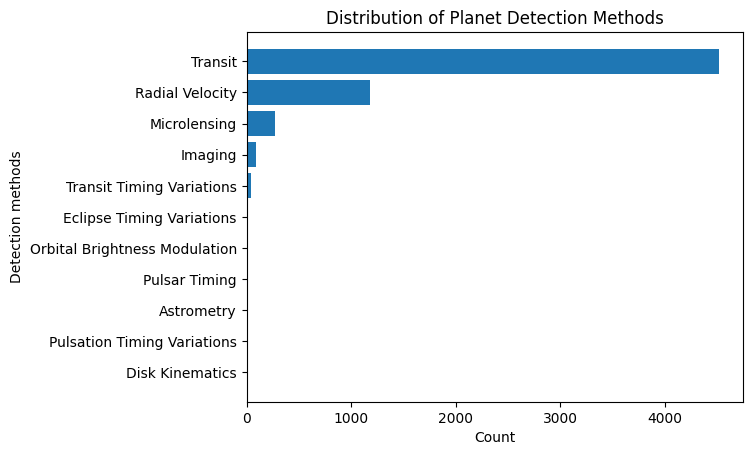

In [159]:
# Visualisation of the distribution of planet detection methods
counts = data['discovery_method'].value_counts()
counts = counts.sort_values()

plt.barh(counts.index, counts.values)
plt.title('Distribution of Planet Detection Methods')
plt.xlabel('Count')
plt.ylabel('Detection methods')
plt.show()

We see that the most popular method to find exoplanets is the transit method. You can learn in detail what the transit method is in the link below:

What is the transit detection method – https://science.nasa.gov/exoplanets/whats-a-transit/

#### Analysis of planet radius relative to Earth's radius
---

In [160]:
data['planet_radius_earth']

0        1.710000
1        3.323214
2        0.800000
3        3.150000
4        4.540605
          ...    
6145    13.800000
6146     1.000000
6147     6.710000
6148     1.382000
6149    13.600000
Name: planet_radius_earth, Length: 6150, dtype: float64

In [161]:
len(data['planet_radius_earth']), sum(data['planet_radius_earth'].isna())

(6150, 50)

In [162]:
# Here we want to explore more detailed information about planets and their radius.
# The main goal is to compare differences between discovery methods
# and the planets they detect (if such differences exist).
data['planet_radius_earth'].describe()

count    6100.000000
mean        5.841983
std         5.436387
min         0.309800
25%         1.820750
50%         2.840000
75%        11.990000
max        87.205870
Name: planet_radius_earth, dtype: float64

In [163]:
# The dataset is filtered by discovery method. These subsets will be used later to analyze specific features.
dm_transit = data[data['discovery_method'] == 'Transit']
dm_radial_velocity = data[data['discovery_method'] == 'Radial Velocity']
dm_microlensing = data[data['discovery_method'] == 'Microlensing']
dm_imaging = data[data['discovery_method'] == 'Imaging']
dm_transit_timing_variations = data[data['discovery_method'] == 'Transit Timing Variations']
dm_eclipse_timing_variations = data[data['discovery_method'] == 'Eclipse Timing Variations']
dm_orbital_brightness_modulation = data[data['discovery_method'] == 'Orbital Brightness Modulation']
dm_pulsar_timing = data[data['discovery_method'] == 'Pulsar Timing']
dm_astrometry = data[data['discovery_method'] == 'Astrometry']
dm_pulsation_timing_variations = data[data['discovery_method'] == 'Pulsation Timing Variations']

In [164]:
def descriptive_info(dataset):
    """
    :param dataset: filtered by discovery method
    :return: descriptive statistics for all numerical features in the dataset
    """
    return dataset.describe()

In [165]:
descriptive_info(dm_transit)

,n_stars,n_planets,disc_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_surface_gravity,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag
count,4517.000000,4517.000000,4516.000000,4517.000000,4516.000000,4494.000000,4299.000000,3978.000000,4264.000000,4515.000000,4517.000000,4517.000000,3838.000000,4515.000000,4400.000000,4502.000000,4512.000000,4517.000000,4517.000000,4517.00000
mean,1.081027,1.771973,2017.343446,23.911908,4.362179,123.375312,922.096155,0.036646,0.125400,5390.889821,1.007880,0.934686,4.328274,4.453200,0.015612,600.235028,13.648186,246.498288,26.920136,0.00155
std,0.305088,1.162517,3.808841,80.853902,4.590506,502.678191,451.356442,0.100164,0.168154,832.415508,0.428345,0.266037,2.944647,0.246748,0.173144,498.597485,1.984631,84.617234,32.294183,0.03934
min,1.000000,1.000000,2002.000000,0.112007,0.309800,0.036400,134.400000,0.000000,0.005000,2566.000000,0.012300,0.089800,0.000000,2.953000,-0.950000,6.869290,5.650000,0.185606,-88.121111,0.00000
25%,1.000000,1.000000,2014.000000,3.824080,1.620000,3.390000,584.000000,0.000000,0.047000,5020.500000,0.770000,0.802000,2.400000,4.320500,-0.070000,223.757000,12.382750,207.526001,11.884058,0.00000
50%,1.000000,1.000000,2016.000000,8.138268,2.426818,6.800000,830.000000,0.000000,0.076100,5597.000000,0.934000,0.940000,3.980000,4.472000,0.020000,492.867500,13.971500,288.164654,41.644643,0.00000
75%,1.000000,2.000000,2021.000000,19.446355,3.960000,19.475000,1166.000000,0.000630,0.139000,5923.000000,1.180000,1.076000,5.300000,4.580000,0.119000,865.308750,15.202250,294.218913,46.379232,0.00000
max,4.000000,8.000000,2026.000000,3650.000000,32.600000,8899.195396,4050.000000,0.941200,4.500000,15900.000000,6.300000,2.780000,16.100000,8.070000,0.560000,8500.000000,19.830000,359.900874,86.860343,1.00000


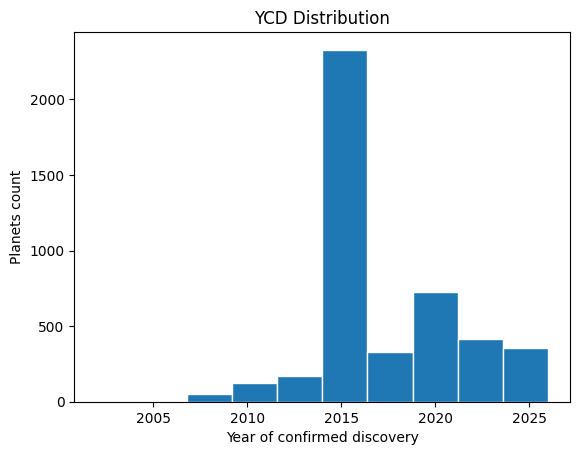

In [166]:
# We analyze when the highest number of exoplanets were confirmed.
# The goal is to gain insight into how the discovery and confirmation of exoplanets evolved over time.
plt.hist(dm_transit['disc_year'], edgecolor='white')
plt.title('YCD Distribution')
plt.xlabel('Year of confirmed discovery')
plt.ylabel('Planets count')
plt.show()

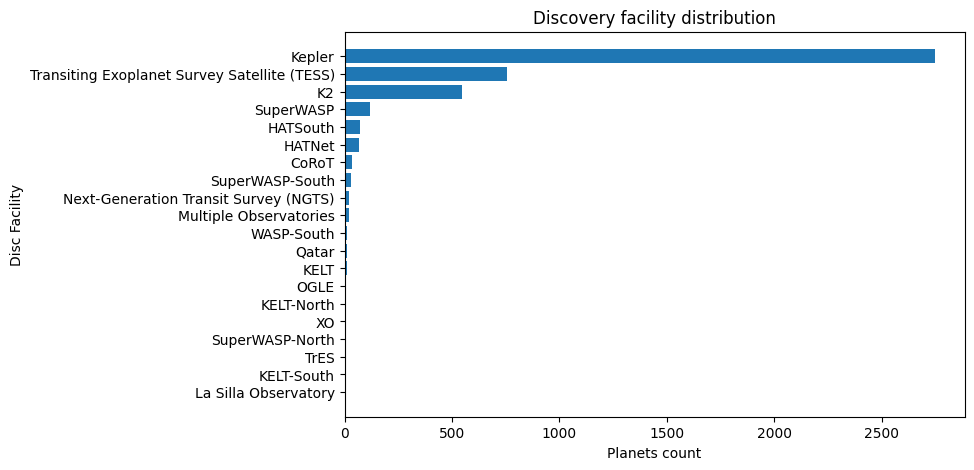

In [167]:
# After observing that the highest number of exoplanets were confirmed in 2015,
# we now examine the facilities used for their detection.
# This analysis focuses only on those that utilize the transit method.
disc_f = dm_transit['disc_facility'].value_counts().head(20).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(disc_f.index, disc_f.values)
plt.title('Discovery facility distribution')
plt.xlabel('Planets count')
plt.ylabel('Disc Facility')
plt.xticks()
plt.show()

##### For now, we will focus on the Kepler, K2, and TESS telescopes.
##### We will explore more details about Kepler, as it clearly dominates exoplanet discoveries.
##### We will also investigate why there is a peak in confirmed exoplanets around 2015.

### Kepler and K2 Missions in relation to the `disc_facility` feature

The Kepler Space Telescope was not replaced by a new spacecraft after a failure. Instead, it experienced a partial technical problem in 2013, when two of its four reaction wheels stopped working. These wheels were essential for maintaining the extremely precise pointing required to detect exoplanets using the transit method.

Without enough working reaction wheels, Kepler could no longer continue its original mission, which focused on continuously observing a single region of the sky. However, the spacecraft itself was still functional.

To solve this problem, engineers developed an innovative solution. They used solar radiation pressure (the force exerted by sunlight) to help stabilize the telescope. By carefully orienting the spacecraft along the ecliptic plane, they were able to balance this pressure and regain sufficient pointing stability.

This new operational mode became the K2 mission. Instead of observing one fixed field, K2 observed different regions of the sky in sequential campaigns, each lasting about three months.

`Source link`: https://science.nasa.gov/mission/kepler/

In [168]:
dm_transit

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.57000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.00000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.43700,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.10000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.70000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6139,K2-290 c,K2-290,3,2,Transit,2019.0,K2,48.366850,11.276254,246.00042,...,234.857885,-20.198898,0,Gas Giant,False,True,False,Mid(100-500pc),F-type,Medium(10-100d)
6144,V1298 Tau d,V1298 Tau,3,4,Transit,2019.0,K2,12.401394,6.530000,6.00000,...,61.331654,20.157032,0,Gas Giant,False,True,False,Mid(100-500pc),K-type,Medium(10-100d)
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.97200,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.40000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)


This is the reason why we observe both "Kepler" and "K2" in the disc_facility column. The Kepler Space Telescope operated under the original Kepler mission from 2009 to 2013, and after a technical issue, it continued operating under a new data collection strategy known as the K2 mission.

Note: The disc_year represents the year of confirmation, not the year of observation. Some data were collected during the original Kepler mission, but the exoplanets were confirmed in later years, including after the spacecraft experienced its technical failure.

But why 2015 is the peak?

The peak in confirmed exoplanets in 2015 is primarily due to the large-scale validation of candidates detected by the Kepler Space Telescope during its main mission (2009–2013).

Although the data were collected earlier, the confirmation process requires time for repeated observations, statistical validation, and analysis. As a result, many exoplanets were confirmed in bulk several years later, leading to a significant increase in confirmed discoveries around 2015.

This peak is therefore not caused by new observations in that year, but by the delayed confirmation of previously collected data.

**Rowe, J.F. et al., 2014. Validation of Kepler’s multiple planet candidates. Available at:** https://arxiv.org/abs/1402.6534, https://iopscience.iop.org/article/10.1088/0004-637X/784/1/45

Other information source: https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS

I still have some doubts, as I was unable to find a source that explicitly explains why 2015 represents a peak in confirmed exoplanets.

### Testing `Detection method vs Planet properties` hypothesis
---
We will use an ANOVA test for this hypothesis, as the data can be divided into multiple groups based on the discovery methods.

In [169]:
# Extract the relevant data required for hypothesis testing
hypotheses_data = data[['discovery_method', 'planet_mass_earth', 'planet_radius_earth']]
hypotheses_data

,discovery_method,planet_mass_earth,planet_radius_earth
0,Transit,3.570000,1.710000
1,Transit,11.000000,3.323214
2,Transit,0.437000,0.800000
3,Transit,10.100000,3.150000
4,Transit,18.700000,4.540605
...,...,...,...
6145,Microlensing,336.898111,13.800000
6146,Transit,0.972000,1.000000
6147,Transit,36.400000,6.710000
6148,Transit,3.280000,1.382000


In [170]:
hypotheses_data['discovery_method'].value_counts()

discovery_method
Transit                          4517
Radial Velocity                  1182
Microlensing                      275
Imaging                            94
Transit Timing Variations          39
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

#### Planet mass relative to Earth

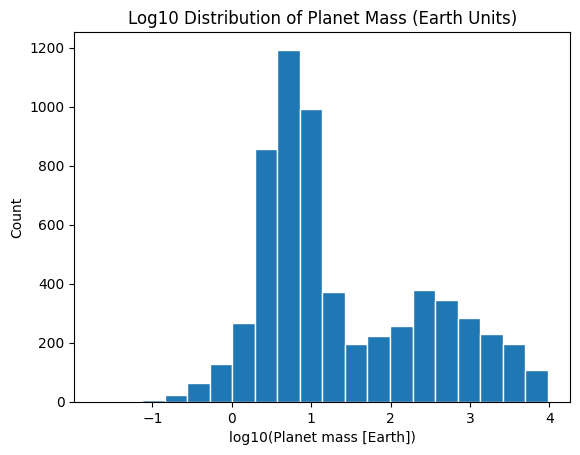

In [171]:
plt.hist(np.log10(hypotheses_data['planet_mass_earth']), bins=20, edgecolor='white')

plt.title('Log10 Distribution of Planet Mass (Earth Units)')
plt.xlabel('log10(Planet mass [Earth])')
plt.ylabel('Count')
plt.show()

In [172]:
hypotheses_data['planet_mass_earth'].describe()

count    6119.000000
mean      406.787994
std      1142.866060
min         0.020000
25%         4.190000
50%         9.270000
75%       190.849000
max      9534.852210
Name: planet_mass_earth, dtype: float64

In [173]:
#dm - discovery method

dm_transit_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Transit'].dropna()
dm_rv_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Radial Velocity'].dropna()
dm_microlensing_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Microlensing'].dropna()
dm_imaging_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Imaging'].dropna()
dm_ttv_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Transit Timing Variations'].dropna()
dm_etv_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Eclipse Timing Variations'].dropna()
dm_obm_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Orbital Brightness Modulation'].dropna()
dm_pt_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Pulsar Timing'].dropna()
dm_astrometry_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Astrometry'].dropna()
dm_ptv_planet_mass_earth = hypotheses_data[['planet_mass_earth']][hypotheses_data['discovery_method'] == 'Pulsation Timing Variations'].dropna()

In [174]:
list_data = [dm_transit_planet_mass_earth, dm_rv_planet_mass_earth, dm_microlensing_planet_mass_earth, dm_imaging_planet_mass_earth, dm_ttv_planet_mass_earth,
             dm_etv_planet_mass_earth, dm_obm_planet_mass_earth, dm_pt_planet_mass_earth, dm_astrometry_planet_mass_earth, dm_ptv_planet_mass_earth]

In [175]:
def show_distribution(dataset):
    """
    :param dataset: filtered dataset. There is only one discovery method in every dataset
    which comes into the function
    :return: None. The function plot a histogram
    """
    plt.hist(np.log10(dataset['planet_mass_earth']), bins=20, edgecolor='white')
    mean_value_planet_mass = np.log10(dataset['planet_mass_earth']).mean()

    plt.title(f"Log10 Distribution of Planet Mass (Earth Units) Method: {dataset.values[0][0]}")

    plt.axvline(mean_value_planet_mass, color='r', label='Mean value')
    plt.xlabel('log10(Planet mass [Earth])')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

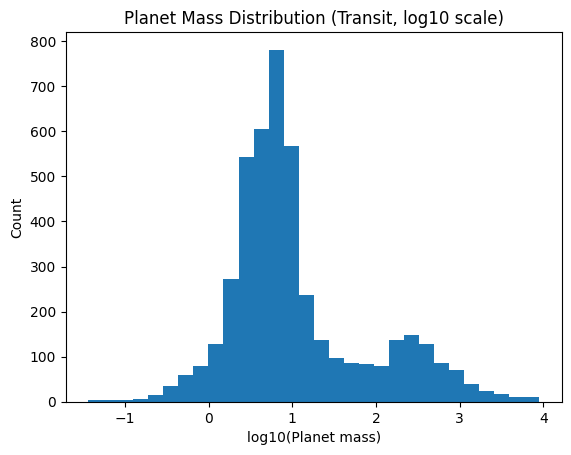

In [176]:
# If we increase the number of bins (e.g., 20, 30, or 40),
# the values on the y-axis decrease because the data is distributed across more intervals.
plt.hist(np.log10(dm_transit_planet_mass_earth['planet_mass_earth']), bins=30)
plt.title('Planet Mass Distribution (Transit, log10 scale)')
plt.xlabel('log10(Planet mass)')
plt.ylabel('Count')
plt.show()

In [177]:
def show_group_hist(*datasets):
    labels = ["Transit", "RV", "Microlensing", "Imaging", "TTV",
              "ETV", "OBM", "PT", "Astrometry", "PTV"]

    data = [np.log10(df['planet_mass_earth'].dropna()) for df in datasets]

    plt.figure(figsize=(12, 6))
    plt.hist(data, bins=30, histtype='step', label=labels)
    plt.xlabel('log10(Planet mass)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

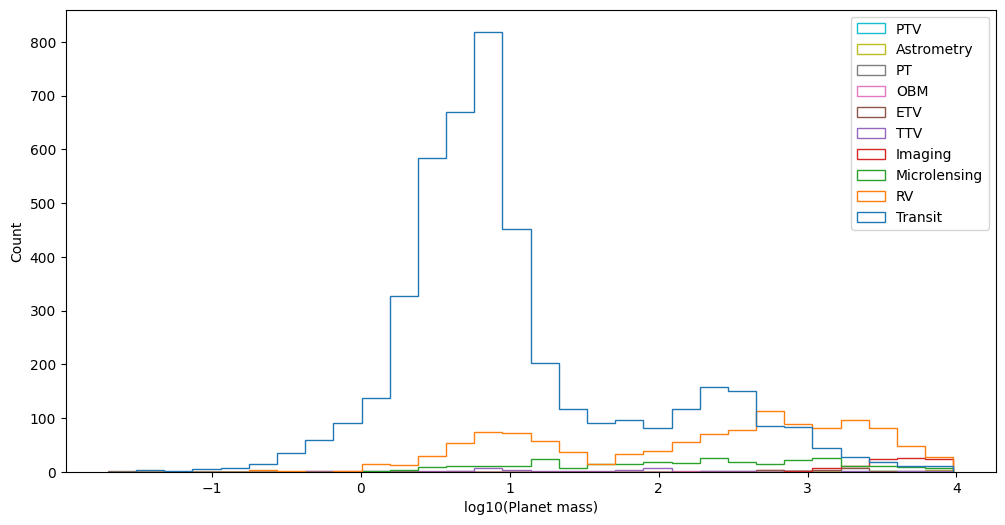

In [178]:
show_group_hist(*list_data)

In [179]:
result = st.f_oneway(*list_data)

p = result[1].item()
print(f"{p:.2e}")

0.00e+00


In [180]:
### pvalue is too low around zero. We reject H0
result

F_onewayResult(statistic=array([311.04535951]), pvalue=array([0.]))